### <p style="text-align: right;"> &#9989; Instructor Solution and Rubric</p>

# __CMSE  201 &ndash; Fall 2021__

<img src="https://cmse.msu.edu/sites/_cmse/assets/Image/image002.jpg"
     alt="CMSE Logo"
     align="right" 
     height="100" 
     width="100" />
     
# Homework 6: Agent Based Modeling 

## Goals

### By the end of the homework assignment you will have practiced:

1. Reviewing the concepts of ABMs
1. Creating an ABM to explore a new idea
1. Analyzing the results of the ABM


## Assignment instructions

Work through the following assignment, making sure to follow all of the directions and answer all of the questions.

**This assignment is due at 11:59pm on Friday, December 10th.** 

It should be uploaded to D2L in the approach "Homework" submission folder.  Submission instructions can be found at the end of the notebook as well.

## Grading

-  Part 0: Academic integrity (1 pt)
-  Part 1: Reviewing ABMs  (6 pts)
-  Part 2: Revisiting the forest fire model (25 pts)
-  Part 3: Analyzing the ABM (14 pts)

**Total:** 46 pts


---
# Part 0: Academic integrity

### &#9989;&nbsp; (1 point): In the markdown cell below, put your personal academic integrity statement. By including this statement, you are confirming that the work you submit in the assignment is wholly your own.

/ Put your personal academic integrity statement here /

---
#  Part 1: Reviewing ABMs

### &#9989;&nbsp; 1.1 (2 points): In your own words, what is an agent-based model?

/ put your answer here /

In [ ]:
### ANSWER ###
# 2 pts total

# 1 pt: anything that highlights modeling
# 1 pt: individuals/agents

# Agent-based models focus on how individual pieces interact with one another, 
# and they can be used to model these interactions on a large scale

### &#9989;&nbsp; 1.2 (4 points): Find an example of an agent-based model from a research study online. Paste a link to the research here. In your own words, what is the model about? How is the model useful for the research?

/ put your answer here /

In [ ]:
### ANSWER ###
# 4 pts total

# 1 pt: Link pasted
# 1.5 pts for answering each question

---
#  Part 2: Revisiting the forest fire model

For this part, you will be revisiting the forest fire project, but with an eye towards forest fire prevention! Instead of modeling a rampant forest fire, you will be modeling the growth of the forest and the practice of [controlled burns](https://www.fs.usda.gov/managing-land/prescribed-fire). With this in mind, we have pasted some fucntions from ICA 19 to help you get started.

### &#9989;&nbsp; 2.1 (4 points): Review the functions below. Something has been changed to make this code more suitable for the model described above. What is it? Why has it been changed?

/ put your answer here /

In [ ]:
### ANSWER ###
# 4 pts total

# 2 pts: What: The set_board function no longer sets a fire on the board
# 2 pts: Why: Because we aren't modeling a rampant forest fire anymore

In [2]:
# standard includes
import numpy as np
import numpy.random as rand
%matplotlib inline
import matplotlib.pyplot as plt

# Next we are going to import some specific libraries we will use to get the animation to work cleanly
from IPython.display import display, clear_output
import time

In [3]:
def plotgrid(myarray):
    
    # First create two vectors based on the x and y sizes of the grid
    x_range = np.linspace(0, myarray.shape[1]-1, myarray.shape[1]) 
    y_range = np.linspace(0, myarray.shape[0]-1, myarray.shape[0])
    
    # Use the numpy meshgrid function to create two matrices
    # of the same size as myarray with x and y indexes
    x_indices, y_indices = np.meshgrid(x_range, y_range)
    
    # Make a list of all the x and y indexes that are either trees or fire.
    tree_x = x_indices[myarray == 1]
    tree_y = y_indices[myarray == 1]
    fire_x = x_indices[myarray == 2] 
    fire_y = y_indices[myarray == 2]
    
    # Plot the trees and fire.
    plt.plot(tree_x, myarray.shape[0] - tree_y - 1, 'gs',markersize=10)   
    plt.plot(fire_x, myarray.shape[0] - fire_y - 1, 'rs',markersize=10)
    
    # Set the x and y limits so we don't cut off the shapes
    plt.xlim([-1,myarray.shape[1]])
    plt.ylim([-1,myarray.shape[0]]) 

    # Removing tick marks
    plt.tick_params(axis='both', which='both',
                    bottom=False, top=False, left=False, right=False,
                    labelbottom=False, labelleft=False)

In [4]:
def set_board(board_size=50,f_trees_start=0.5):
    '''
    Creates the initial game board.

    Inputs:
        board_size: length of one edge of the board
        f_trees_start: probability that a given cell is a tree
                       (effectively the tree density)

    Outputs a 2D numpy array with values set to either 0, 1, or 2
        (empty, tree, or fire)
    '''
    
    # all cells initialized to 'empty' (0) by default
    game_board = np.zeros((board_size,board_size),dtype='int64')
    
    # loop over board and roll the dice; if the random number is less
    # than f_trees_start, make it a tree.
    for i in range(board_size):
        for j in range(board_size):
            if rand.random() <= f_trees_start:
                game_board[i,j] = 1
    
    return game_board

In [5]:
def on_board(i, j, board):
    if i <= board.shape[0]-1 and i >= 0 and j <= board.shape[1]-1 and j >= 0:
        return True
    else:
        return False

def get_neighbor_values(i,j, board):
    neighborhood = [(i-1, j), (i, j-1), (i+1, j), (i, j+1)]
    
    neighbor_values = []
    for neighbor in neighborhood:
        if on_board(neighbor[0], neighbor[1], board):
            neighbor_values.append(board[neighbor[0], neighbor[1]])
    
    return neighbor_values

---
The code below runs the animation for forest growth and controlled burns. If you run it, you will get an error. That's because you still need to define some of the functions that the ABM needs!

### &#9989;&nbsp; 2.2 (5 points): Review the code below. At each empty comment (there are five, denoted by the lone hashtags), write a comment that describes what the chunk of code directly below it is supposed to be doing.

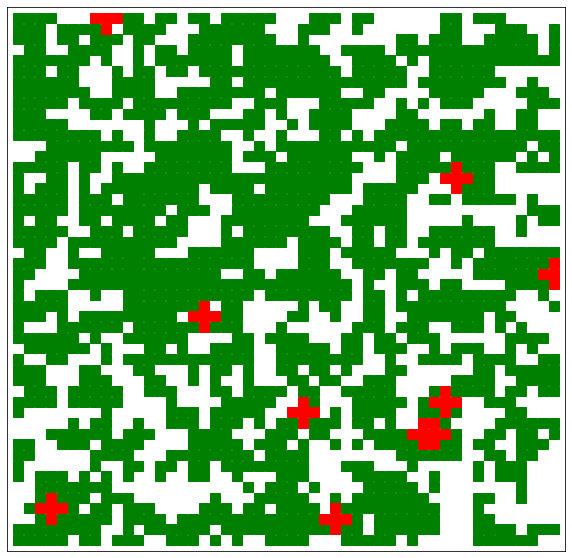

In [17]:
f_trees_start = 0.5
board_size = 50

reproduction_rate = 0.02   # the probability of a tree reproducing in a given empty neighboring spot
burns = 10                 # controlled burns per year in the board area

fig = plt.figure(figsize=(10,10))

board = set_board(board_size=board_size, f_trees_start=f_trees_start)

plotgrid(board)

#
year = 0
end = 25

#
while year < end:
    
    #
    board = reset_burns(board)
    board = controlled_burns(board, burns)
    board = tree_reproduction(board, reproduction_rate)
    
    #
    plotgrid(board)
    time.sleep(0.5)
    clear_output(wait=True)
    display(fig)
    fig.clear()
    
    #
    year += 1

plt.close()

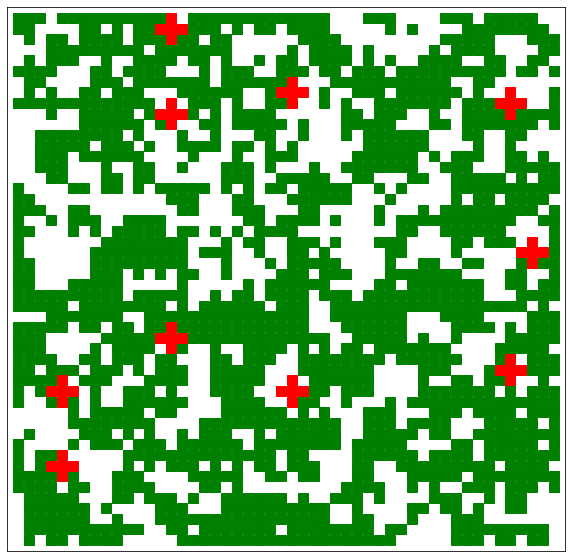

In [16]:
### ANSWER ###
# 5 pts total

# 1 pt for each comment

f_trees_start = 0.5
board_size = 50

reproduction_rate = 0.02   # the probability of a tree reproducing in a given empty neighboring spot
burns = 10                 # controlled burns per year in the board area

fig = plt.figure(figsize=(10,10))

board = set_board(board_size=board_size, f_trees_start=f_trees_start)

plotgrid(board)

# defining span of years for the model
year = 0
end = 25

# while loop runs until we reach the last year
while year < end:
    
    # controlled burns die, new controlled burns happen, and trees reproduce
    board = reset_burns(board)
    board = controlled_burns(board, burns)
    board = tree_reproduction(board, reproduction_rate)
    
    # visualize the model at each step
    plotgrid(board)
    time.sleep(0.5)
    clear_output(wait=True)
    display(fig)
    fig.clear()
    
    # increment the year
    year += 1

plt.close()

### In case you delete some of the code above on accident, here it is again, just copy and paste as needed.

    f_trees_start = 0.5
    board_size = 50

    reproduction_rate = 0.02    # the probability of a tree reproducing in a given empty neighboring spot
    burns = 10                  # controlled burns per year in the board area

    fig = plt.figure(figsize=(10,10))

    board = set_board(board_size=board_size, f_trees_start=f_trees_start)

    plotgrid(board)
    
    #
    year = 0
    end = 25
    
    #
    while year < end:
        
        #
        board = reset_burns(board)
        board = controlled_burns(board, burns)
        board = tree_reproduction(board, reproduction_rate)
        
        #
        plotgrid(board)
        time.sleep(0.5)
        clear_output(wait=True)
        display(fig)
        fig.clear()
        
        #
        year += 1

    plt.close()

---
The `reset_burns` function is meant to reset all fires to be empty cells. The input is a board. The output is a board with all the same values, but the fires have been set to empty.

### &#9989;&nbsp; 2.3 (3 points): Create the `reset_burns` function in the cell below.

In [ ]:
# your answer here

In [7]:
### ANSWER ###
# 3 pts total

# 1 pt for inputting and outputting a board
# 1 pt for setting up nested loop
# 1 pt for resetting fires to empty

def reset_burns(board):
    for i in range(len(board)):
        for j in range(len(board[0])):
            if board[i, j] == 2:
                board[i, j] = 0
    return board

---
The `controlled_burns` function is meant to carry out the controlled burns. Each controlled burn picks a cell at random, and sets fire to that cell and its neighbors. Don't worry, the fire will not spread further than this, thanks to the `reset_burns` function from above. The picture below shows an example of what the controlled burns would look like if they happened 10 burns at once.

<img src="controlled_burns.png" width=500 height=500 />

To review how the function should work:
* Input: a board, a number of burns
* Output: a board
* the outputted board should have a number of randomly located controlled burns applied to it, according to the inputs

### &#9989;&nbsp; 2.4 (6 points): Create the `controlled_burns` function in the cell below.

In [8]:
# your answer here

In [9]:
### ANSWER ###
# 6 pts total

# 1 pt for inputting a board and a number
# 1 pt for setting up a loop to perform the right number of burns
# 1 pt for selecting a random location for each burn
# 1 pt for applying burn to neighbors
# 1 pt for handling edge cases (using on_board, or something similar)
# 1 pt for returning the modified board

def controlled_burns(board, num_burns):
    height = len(board)
    width = len(board[0])
    
    while num_burns > 0:
        i = rand.randint(0, height)
        j = rand.randint(0, width)

        neighborhood = [(i, j), (i-1, j), (i, j-1), (i+1, j), (i, j+1)]
        for neighbor in neighborhood:
            if on_board(neighbor[0], neighbor[1], board):
                board[neighbor[0], neighbor[1]] = 2
        
        num_burns -= 1
    
    return board

---
The `tree_reproduction` function is meant to give the trees a chance to reproduce in neighboring empty cells. Each empty cell has a chance of producing a tree, depending on the reproduction rate of the forest and the number of adjacent trees. The probability of an empty spot yielding a tree is governed by the equation below.

$$p = n * r$$

* $p$ is the probability that an empty spot will yield a tree in a given year
* $n$ is the number of trees neighboring the empty spot
* $r$ is the reproduction rate

To review how the function should work:
* Input: a board, a reproduction rate
* Output: a board
* The outputted board should have several more trees than the inputted board. the new trees should be on previously empty spots, according the equation above

### &#9989;&nbsp; 2.5 (6 points): Create the `tree_reproduction` function in the cell below.

In [10]:
# your answer here

In [11]:
### ANSWER ###
# 6 pts total

# 1 pt for inputting a board and a number
# 1 pt for checking every empty spot on the board
# 1 pt for counting the neighboring trees
# 1 pt for implementing the p = n * r equation in some form
# 1 pt for randomly adding a tree based on p
# 1 pt for returning the modified board

def tree_reproduction(board, rate):
    for i in range(len(board)):
        for j in range(len(board[0])):
            
            if board[i, j] == 0: # an empty spot
                neighbors = get_neighbor_values(i, j, board)
                
                # n is the number of neighboring trees
                n = neighbors.count(1)
                
                p = n * rate
                if rand.random() < p:
                    board[i, j] = 1
    return board

---
### Go back and run the cell in 2.2. If the animation runs and you can see trees reproducing and the controlled burns happening, then you know your functions are working.

---
#  Part 3: Analyzing the new ABM

You might remember from ICA 19 that the tipping point for a forest in danger of forest fires was right around where the density of the forest was 0.6. Your job is to make a recommendation on how many controlled burns need to be carried out per year to keep a forest from becoming too dangerous. The forest's current condition:

* size: 100 by 100
* initial density of trees: 0.55
* reproduction rate of trees: 0.02
* controlled burns per year: **up to you!**

To make a convincing recommendation, you will need to produce a plot that shows how the forest's density changes over **the next 100 years**.

To help you, we've supplied a function to calculate the forest density of the board.

In [12]:
def forest_density(board):
    return (board == 1).sum() / board.size

### &#9989;&nbsp; 3.1 (6 points): Write code and produce a plot of forest densities versus years for the next 100 years. It might help to have some of the code from 2.2, so we pasted it below and stripped away the animation stuff.

    f_trees_start = 0.5
    board_size = 50

    reproduction_rate = 0.02    # the probability of a tree reproducing in a given empty neighboring spot
    burns = 10                  # controlled burns per year in the board area

    board = set_board(board_size=board_size, f_trees_start=f_trees_start)

    year = 0
    end = 25

    while year < end:

        board = reset_burns(board)
        board = controlled_burns(board, burns)
        board = tree_reproduction(board, reproduction_rate)

        year += 1

In [13]:
# your answer here

Text(0.5, 1.0, 'Density of the forest over the years')

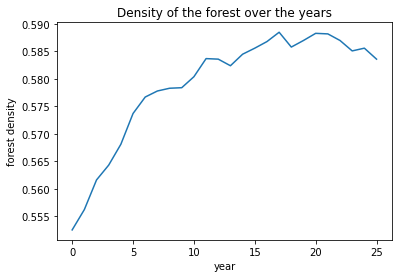

In [14]:
### ANSWER ###
# 6 pts total

# 1 pt for copying the code above or rewriting their own code to do a similar process
# 0.5 pt for changing f_trees_start to 0.55
# 0.5 pt for changing board_size to 100
# 0.5 pt for creating new lists to track the years and the densities
# 0.5 pt for appending values into those lists in the loop
# 1 pt for creating a plot to show density over time
# 1 pt for modifying the burn rate
# 1 pt if their plot shows long term density staying below 0.6

f_trees_start = 0.55
board_size = 100

reproduction_rate = 0.02
burns = 50

board = set_board(board_size=board_size, f_trees_start=f_trees_start)

year = 0
end = 25

years = [0]
densities = [forest_density(board)]

while year < end:
    
    board = reset_burns(board)
    board = controlled_burns(board, burns)
    board = tree_reproduction(board, reproduction_rate)
    
    year += 1
    
    years.append(year)
    densities.append(forest_density(board))

plt.plot(years, densities)
plt.xlabel("year")
plt.ylabel("forest density")
plt.title("Density of the forest over the years")

---
Now it's time to make your recommendation... If your plot showed the forest going above 0.6 in density, you might want to go back to 3.1 and change the number of controlled burns

### &#9989;&nbsp; 3.2 (4 points): How many controlled burns per year should be carried out in this forest? Use your plot to justify your answer. Your recommendation should have enough controlled burns to keep the forest below 0.6 density over the next 100 years, but also don't make the forest wither away from too many controlled burns (and an over-funded fire department).

/ your answer here /

In [15]:
### ANSWER ###
# 4 pts total

# 2 pts if their answer involves raising the number of burns above 10
# 2 pts if they reference their plot as justification,
#       and their answer matches the number of burns they used to make the plot

---
In an ABM, as with any model, there are assumptions baked into it. For example, when we modeled forest fires in class, we assumed there was no wind, we assumed every tree was the same size, and we assumed the fire spread between trees that touched but never between trees that were diagonal. These assumptions helped us translate the model into code, but they also constrain the real world application of the model (What if it's a really windy day? What then??!)

### &#9989;&nbsp; 3.3 (4 points): List four assumptions that were part of the controlled burns model.

/ your answer here /

In [ ]:
### ANSWER ###
# 4 pts total

# 1 pt for each assumption

# Some examples:
# * controlled burns are all the same shape/size
# * all trees have the same reproductive qualities
# * there are no uncontrolled forest fires in this forest
# * 0.6 is a good density even if the trees aren't uniformly distributed
# * controlled burns happen at completely random locations
# * the risk of forest fires does not change over a 100 year span

---

### Congratulations, you're done!

Submit this assignment by uploading it to the course Desire2Learn web page.  
Go to the "Homework Assignments" section, find the appropriate submission folder link, and upload it there.


&#169; Copyright 2020, [Department of Computational Mathematics, Science and Engineering](https://cmse.msu.edu) at Michigan State University.